<div style='font-size:14px'>Now what if we need to merge data in order to analyse it further like in last one if we need to compare data jobs with tech field jobs then we need to merge them using merge method

In [1]:
import pandas as pd

df_companies = pd.DataFrame({
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'industry': ['Technology', 'Technology', 'Technology', 'Apparel', 'Food & Beverage'],
    'company_size': ['100,000+', '100,000+', '100,000+', '75,000+', '346,000+']
})

df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [ ]:
import pandas as pd

df_jobs = pd.DataFrame({
    'job_id': [1, 2, 3, 4, 5],
    'job_title': [
        'Data Scientist',
        'Software Engineer',
        'Product Manager',
        'Marketing Director',
        'HR Manager'
    ],
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'job_location': [
        'Mountain View, CA',
        'Redmond, WA',
        'Cupertino, CA',
        'Beaverton, OR',
        'Seattle, WA'
    ]
})

df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


<div style='font-size:14px'>now we will merge these two tables using merge method it has a few parameters which are: right parameter which indicates the object to merge with, on parameter:Column or index level names to join on(if they have one same column_name).If no same column name exist then left_on or right_on is used, how parameter: this tells how to merge the tables its kind of similar to joins in sql like left right inner or full,

In [5]:
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

In [8]:
df_India = df[df['job_country']=='India'].copy()

In [9]:
df_India['job_posted_month'] = df_India['job_posted_date'].dt.strftime('%B')

In [10]:
df_India_pivot = df_India.pivot_table(
    index= 'job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

In [11]:
df_India_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,170,32,418,1566,946,54,86,375,194,169
August,189,25,618,1407,1157,47,126,343,235,148
December,186,27,648,1464,1206,94,77,343,200,133
February,143,35,433,1631,932,42,94,313,165,157
January,175,31,628,2132,1444,70,127,448,269,192
July,142,25,457,1528,1123,54,75,359,204,155
June,146,26,367,1632,1129,41,66,427,238,125
March,116,37,422,1591,1005,34,96,351,194,180
May,103,14,278,1384,837,31,59,329,134,98


In [15]:
df_India_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col = 'job_posted_month')

In [18]:
df_India_merged = df_India_pivot.merge(df_India_software_pivot, on='job_posted_month')

In [24]:
top_5=df_India_merged.sum().sort_values(ascending=False).head().index.to_list()

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

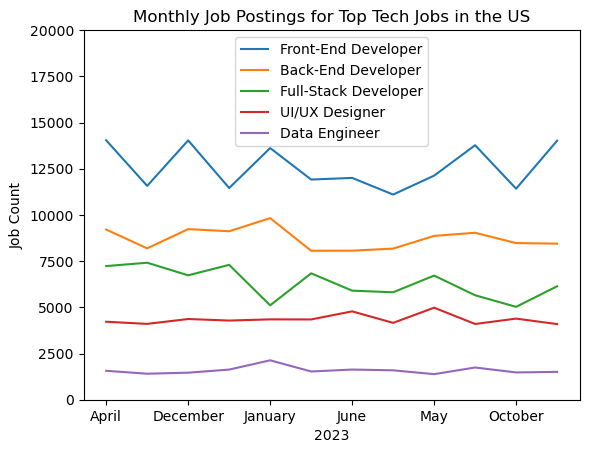

In [26]:
df_India_merged[top_5].plot(kind='line')
plt.title('Monthly Job Postings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()